# Wikipedia pageviews (Lane A: you prompt, the agent builds)

**SISMID 2026 - Day 2, 9:00.** Drive **Codex / Claude Code / Antigravity CLI**. Each prompt
produces roughly the matching cell in the Lane B notebook. Not set up? Use Lane B.


## Step 0: point the agent at the task

> *Using the public Wikimedia REST pageviews API (no key), write `wiki_fetch(article,*
> *wiki, start, end)` returning a tidy DataFrame (date, views), and a `load_cache()` that*
> *reads `data/wikipedia_dengue_pageviews_cached.csv`. Add `get_dengue_wiki()` that pulls*
> *English (Dengue_fever), Spanish (Dengue), Portuguese (Dengue), merges on date, and*
> *falls back to the cache on any failure. Set a descriptive User-Agent.*


In [1]:
import urllib.request, json, os
import pandas as pd

USER_AGENT = 'SISMID2026-course/1.0 (your-email@example.com)'   # put a real contact
CACHE_PATHS = ['../data/wikipedia_dengue_pageviews_cached.csv',
               'data/wikipedia_dengue_pageviews_cached.csv',
               './wikipedia_dengue_pageviews_cached.csv']

def wiki_fetch(article, wiki, start='2016010100', end='2025120100'):
    """Monthly Wikipedia pageviews for one article. Returns DataFrame(date, views) or None."""
    url = (f'https://wikimedia.org/api/rest_v1/metrics/pageviews/per-article/'
           f'{wiki}/all-access/all-agents/{article}/monthly/{start}/{end}')
    try:
        req = urllib.request.Request(url, headers={'User-Agent': USER_AGENT})
        items = json.loads(urllib.request.urlopen(req, timeout=30).read())['items']
        return pd.DataFrame([{'date': pd.to_datetime(it['timestamp'][:8], format='%Y%m%d'),
                              'views': it['views']} for it in items])
    except Exception as e:
        print(f'Wikipedia live pull failed ({type(e).__name__}): {e}')
        return None

def load_cache():
    for p in CACHE_PATHS:
        if os.path.exists(p):
            print(f'Using cached snapshot: {p}')
            return pd.read_csv(p, parse_dates=['date'])
    raise FileNotFoundError('Wikipedia cache not found; check the data/ folder.')

def get_dengue_wiki():
    en = wiki_fetch('Dengue_fever', 'en.wikipedia')
    es = wiki_fetch('Dengue', 'es.wikipedia')
    pt = wiki_fetch('Dengue', 'pt.wikipedia')
    if en is None or es is None or pt is None:
        return load_cache()   # any failure -> the merged cached snapshot
    return (en.rename(columns={'views':'dengue_en'})
              .merge(es.rename(columns={'views':'dengue_es'}), on='date')
              .merge(pt.rename(columns={'views':'dengue_pt'}), on='date'))


## Step 1: pull three languages and overlay

> *Use get_dengue_wiki() to build the merged frame; print the row count and date range,*
> *and overlay the three language series on one plot.*

**Your check:** do the peaks line up with dengue seasons in those regions?


rows: 120 | range: 2016-01-01 to 2025-12-01


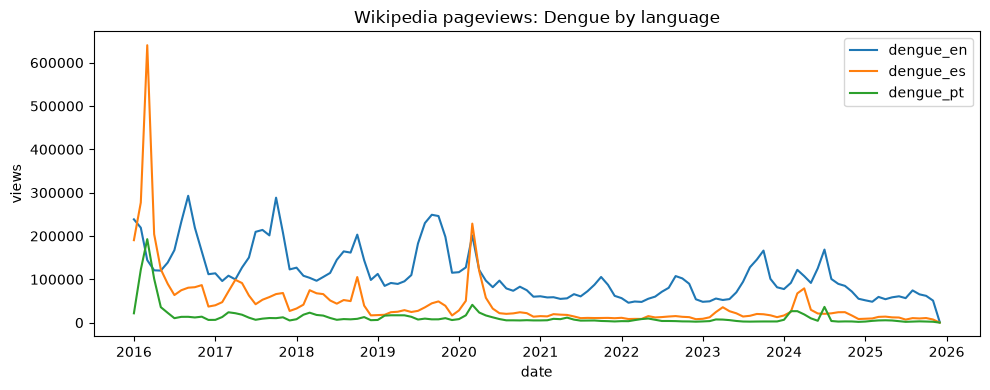

,date,dengue_en,dengue_es,dengue_pt
115,2025-08-01,74438,10508,2474
116,2025-09-01,65370,9714,3010
117,2025-10-01,61894,10687,2601
118,2025-11-01,50965,7285,2121
119,2025-12-01,1508,217,90


In [2]:
import matplotlib.pyplot as plt

df = get_dengue_wiki()
print('rows:', len(df), '| range:', df['date'].min().date(), 'to', df['date'].max().date())

cols = [c for c in df.columns if c != 'date']
plt.figure(figsize=(10, 4))
for c in cols:
    plt.plot(df['date'], df[c], label=c)
plt.legend(); plt.title('Wikipedia pageviews: Dengue by language'); plt.ylabel('views')
plt.xlabel('date'); plt.tight_layout(); plt.show()
df.tail()


## Step 2: reproducibility

> *Pull the English series twice and report whether the two pulls are identical.*

They should be - the contrast with Google Trends' sampling noise.


In [3]:
a = wiki_fetch('Dengue_fever', 'en.wikipedia')
b = wiki_fetch('Dengue_fever', 'en.wikipedia')
if a is not None and b is not None:
    print('identical pulls?', a['views'].equals(b['views']))
else:
    print('live unavailable; from the cache this series is fixed anyway.')


identical pulls? True


## Step 3: sanity-check and save

> *Report missing values per column and the correlation between the language series,*
> *then save the merged frame to `dengue_wikipedia.csv` and confirm.*


In [4]:
print('missing per column:'); print(df.isna().sum())
print('\ncorrelation between languages:'); print(df[cols].corr().round(2))

df.to_csv('dengue_wikipedia.csv', index=False)
print('saved dengue_wikipedia.csv', df.shape)


missing per column:
date         0
dengue_en    0
dengue_es    0
dengue_pt    0
dtype: int64

correlation between languages:
           dengue_en  dengue_es  dengue_pt
dengue_en       1.00       0.39       0.24
dengue_es       0.39       1.00       0.92
dengue_pt       0.24       0.92       1.00
saved dengue_wikipedia.csv (120, 4)


## Reflection

- You described outcomes and checks; the agent wrote the API plumbing.
- Wikipedia is the well-behaved stream; the same loop you used on Google Trends works.
- **Stretch:** swap in your own disease/article and languages.
